# Configuración 3: 1D-CNN (a) + PINN (b) + autoatención (d)

**Anexo de código del TFM.** Pronóstico de crecimiento de grietas por fatiga (PHM Data Challenge 2019).
Carlos J. Bravo I.

La Configuración 3 cambia una sola cosa respecto de la Configuración 1. En la Configuración 1 la
cabeza que identifica el coeficiente de la ley de crecimiento promedia con peso igual la
representación latente de todas las ondas del espécimen,

$$\log_{10}C = f\!\left(\frac{1}{K}\sum_k z_k\right)$$

y aquí ese promedio se sustituye por una ponderación aprendida sobre la secuencia de ciclos,

$$\log_{10}C = f\big(\mathrm{Attn}(z_1,\dots,z_K)\big)$$

La cabeza que estima la longitud de grieta no se toca. De ese modo la ablación aísla la contribución
del componente añadido al problema que debe resolver, en lugar de mezclarla con cambios en la
estimación. Todo lo demás se hereda sin cambios de la Configuración 1: el preprocesado, el
protocolo, la pérdida, los hiperparámetros físicos y la cota de extrapolación.

## Contenido

| Apartado | Contenido |
|---|---|
| 1 | El componente añadido |
| 2 | El mecanismo de ponderación |
| 3 | Dimensionamiento del mecanismo |
| 4 | Entrenamiento e inferencia |
| 5 | Evaluación sobre T7 y T8 |
| 6 | Comparación con la Configuración 1 |
| 7 | La ponderación que el mecanismo aprende |
| 8 | El alcance de la ponderación sobre T8 |
| 9 | Conclusiones |
| 10 | Limitaciones |

In [ ]:
import sys, time, warnings
from pathlib import Path

warnings.filterwarnings("ignore")
RAIZ = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / "config1_cnn_pinn" / "model.py").is_file())
if str(RAIZ) not in sys.path:
    sys.path.insert(0, str(RAIZ))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display

torch.set_num_threads(4)
pd.set_option("display.width", 210)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": .3,
                     "axes.spines.top": False, "axes.spines.right": False})

from dataclasses import asdict

from matplotlib.ticker import FuncFormatter, NullFormatter

from config1_cnn_pinn.data import build_specimen_batches, load_labels
from config1_cnn_pinn.evaluate import (ABLATION, build_submission, n_observed_nonzero,
                                       summarise)
from config1_cnn_pinn.model import CnnPinn
from config1_cnn_pinn.physics import equivalent_stress_range, fit_log_c
from config1_cnn_pinn.train import Config, TRAIN_POOL, train_ensemble
from config3_attention.model import CnnAttentionPinn
from physics_calibration.data import load_curve
from referencias_phm import PUBLICADO, REPLICA

MARCA_DE_AGUA = "Carlos J. Bravo (2026)"


def marca_de_agua(fig, texto=MARCA_DE_AGUA):
    fig.text(0.995, 0.004, texto, fontsize=8, color="0.45", alpha=0.38,
             ha="right", va="bottom", fontweight="bold")
    return fig


BASE = "Config 1 (promedio de peso igual)"
ATEN = "Config 3 (ponderación aprendida)"
N_TANDAS = 4
INICIO = time.perf_counter()

from pesos_entrenados import cargar_o_entrenar, inventario

# Los pesos se guardan en models/ y se reutilizan: entrenar de cero sólo cambia
# el tiempo, no el resultado, porque la siembra está fijada. Poner a True para
# rehacer el entrenamiento e ignorar lo guardado.
ENTRENAR_DE_NUEVO = False


## 1. El componente añadido

El diagnóstico de la Configuración 1 localiza su error en un único escalar. La estimación de la
longitud de grieta sobre la ventana con señal es correcta en las dos probetas; lo que se desvía es el
coeficiente con el que se extrapola después, y en T8 se desvía casi cuatro décimas de década respecto
del que su propia curva implica.

Promediar con peso igual trata por igual dos cosas que no lo son: el ciclo de referencia sano, que
por construcción no contiene daño y cuyo canal diferencial es idénticamente nulo, y los ciclos que sí
informan de la velocidad de crecimiento. La ponderación aprendida sustituye ese promedio y es, por
tanto, un mecanismo dirigido exactamente a la magnitud que falla.

### 1.1 La hipótesis y lo que el conjunto de datos permite contrastar

La hipótesis de partida es que una ponderación sobre el historial completo permita reconocer que un
espécimen está sometido a otro régimen de carga. El conjunto de datos no permite contrastarla:
ninguno de los seis especímenes de entrenamiento es de amplitud variable, y el único que lo es, T8,
es el de evaluación. No se puede aprender a reconocer un régimen del que no hay ningún ejemplo, y
ninguna arquitectura sortea esa restricción.

Lo que sí puede contrastarse con estos datos, y sin mirar a T7 ni a T8, es si la ponderación aprende
a descontar los ciclos poco informativos. El apartado 7 lo mide directamente. El apartado 8 mide
aparte por qué el coeficiente de T8 queda fuera del alcance de cualquier ponderación.

## 2. El mecanismo de ponderación

El mecanismo trabaja sobre la secuencia de ciclos de cada espécimen y produce el vector que alimenta
a la cabeza del coeficiente. Consta de cuatro piezas.

**Un elemento por ciclo, no por onda.** Las dos repeticiones de una misma medida son casi idénticas y
entrarían como información duplicada, de modo que se promedian antes.

**Posición dada por el hueco temporal, no por el índice.** La secuencia no es uniforme en ciclos: los
huecos van de quinientos a treinta y seis mil. La posición útil es, por tanto, el hueco y el avance
relativo, y no el número de orden. Se inicializa a cero para que al comienzo del entrenamiento no
perturbe.

**Una capa de autoatención bidireccional**, en la que cada ciclo puede atender a todos los demás, con
normalización de capa y una red densa posterior.

**Una consulta aprendida** que resume la secuencia en un único vector. Es la que decide a qué ciclos
mirar para estimar el coeficiente, y sus pesos son los que se leen en el apartado 7.

In [2]:
cfg_base = Config(**ABLATION["Configuración 1 (1D-CNN + PINN)"])
cfg_aten = Config(**{**ABLATION["Configuración 1 (1D-CNN + PINN)"],
                     "architecture": "cnn_attention_pinn"})
COTA = cfg_base.cota_entrega_mm

etiquetas = load_labels()
lotes = build_specimen_batches(etiquetas, cfg_base.m_exponent)
n_desc = int(next(iter(lotes.values())).features.shape[1])

m_base = CnnPinn(log_c_prior=cfg_base.log_c_prior, log_c_range=cfg_base.log_c_range,
                 channels=cfg_base.channels, latent=cfg_base.latent,
                 dropout=cfg_base.dropout, n_features=n_desc)
m_aten = CnnAttentionPinn(log_c_prior=cfg_aten.log_c_prior, log_c_range=cfg_aten.log_c_range,
                          channels=cfg_aten.channels, latent=cfg_aten.latent,
                          dropout=cfg_aten.dropout, n_features=n_desc,
                          n_heads=cfg_aten.n_heads, attn_dropout=cfg_aten.attn_dropout)

print(f"Configuración heredada: {cfg_base.epochs} épocas, dropout {cfg_base.dropout}, "
      f"peso de ancla x{cfg_base.anchor_weight:.0f}, m = {cfg_base.m_exponent:.2f}, "
      f"cota de entrega {COTA} mm")
print(f"\n{BASE:34s} {m_base.n_parameters():>8,d} parámetros")
print(f"{ATEN:34s} {m_aten.n_parameters():>8,d} parámetros")
print(f"{'coste del componente añadido':34s} {m_aten.n_parameters()-m_base.n_parameters():>+8,d} "
      f"({100*(m_aten.n_parameters()/m_base.n_parameters()-1):.0f} %)")

Configuración heredada: 600 épocas, dropout 0.3, peso de ancla x48, m = 2.00, cota de entrega 7.24 mm

Config 1 (promedio de peso igual)    10,274 parámetros
Config 3 (ponderación aprendida)     18,946 parámetros
coste del componente añadido         +8,672 (84 %)


## 3. Dimensionamiento del mecanismo

Las secuencias de este conjunto de datos tienen entre tres y nueve ciclos, y las dos probetas de
evaluación tienen cuatro. El tamaño de la muestra fija por tanto las dimensiones del mecanismo, que
se mantiene en el mínimo con el que la ponderación es posible.

In [3]:
display(pd.DataFrame([
    ("Capas de atención", "1", "secuencias de tres a nueve ciclos"),
    ("Cabezales", f"{cfg_aten.n_heads}", "el mínimo que permite más de una vista"),
    ("Dimensión de trabajo", f"{cfg_aten.latent}", "la del latente ya existente, no una nueva"),
    ("Desconexión aleatoria en la atención", f"{cfg_aten.attn_dropout}", "heredada de la base"),
    ("Elemento de la secuencia", "uno por ciclo", "las repeticiones se promedian"),
    ("Posición", "hueco de ciclos y avance relativo", "la secuencia no es uniforme"),
    ("Alcance", "sólo la cabeza del coeficiente", "la de grieta queda igual a la Configuración 1"),
    ("Dirección", "bidireccional", "transductiva; se declara en las limitaciones"),
], columns=["parámetro", "valor", "motivo"]))

print("\nLongitud de la secuencia por espécimen:")
for n, b in lotes.items():
    print(f"  {n}: {len(torch.unique(b.cycles)):>2d} ciclos  ({b.x.shape[0]} ondas)")

,parámetro,valor,motivo
0,Capas de atención,1,secuencias de tres a nueve ciclos
1,Cabezales,2,el mínimo que permite más de una vista
2,Dimensión de trabajo,32,"la del latente ya existente, no una nueva"
3,Desconexión aleatoria en la atención,0.1,heredada de la base
4,Elemento de la secuencia,uno por ciclo,las repeticiones se promedian
5,Posición,hueco de ciclos y avance relativo,la secuencia no es uniforme
6,Alcance,sólo la cabeza del coeficiente,la de grieta queda igual a la Configuración 1
7,Dirección,bidireccional,transductiva; se declara en las limitaciones



Longitud de la secuencia por espécimen:
  T1:  7 ciclos  (14 ondas)
  T2:  3 ciclos  (6 ondas)
  T3:  9 ciclos  (18 ondas)
  T4:  8 ciclos  (16 ondas)
  T5:  3 ciclos  (5 ondas)
  T6:  6 ciclos  (12 ondas)
  T7:  4 ciclos  (8 ondas)
  T8:  4 ciclos  (8 ondas)


## 4. Entrenamiento e inferencia

Las dos arquitecturas se entrenan con las mismas semillas, de modo que la comparación del apartado 6
varía en una sola cosa. Se entrenan además cuatro tandas de semillas independientes por arquitectura:
la primera es la que se reporta y el conjunto de las cuatro da el recorrido que el apartado 6.1
utiliza para decidir qué diferencias son atribuibles al mecanismo.

In [ ]:
nombres = [n for n in TRAIN_POOL if n in lotes]
CLAVE = {BASE: "base", ATEN: "atencion"}
tandas, entregas_tanda, tiempos = {}, {}, {}
for etiqueta, cfg in ((BASE, cfg_base), (ATEN, cfg_aten)):
    tandas[etiqueta], entregas_tanda[etiqueta], tiempos[etiqueta] = [], [], 0.0
    for k in range(N_TANDAS):
        c = Config(**{**asdict(cfg), "seed": k})
        modelos, segundos, procedencia = cargar_o_entrenar(
            f"config3/{CLAVE[etiqueta]}_tanda{k}", c,
            lambda c=c: train_ensemble(c, lotes, nombres, n_seeds=5),
            forzar=ENTRENAR_DE_NUEVO, entrenados_sobre=nombres,
            notas=f"{etiqueta}, tanda {k} de {N_TANDAS}, 5 semillas.")
        tandas[etiqueta].append(modelos)
        tiempos[etiqueta] += segundos
        entregas_tanda[etiqueta].append(
            [build_submission(modelos, lotes, c, n) for n in ("T7", "T8")])
    print(f"{etiqueta:34s} {N_TANDAS} tandas de 5 semillas en {tiempos[etiqueta]:6.0f} s "
          f"({procedencia})")

entregas = {e: entregas_tanda[e][0] for e in (BASE, ATEN)}
print(f"\nSobrecoste del mecanismo en entrenamiento: "
      f"{100*(tiempos[ATEN]/tiempos[BASE]-1):.0f} %")


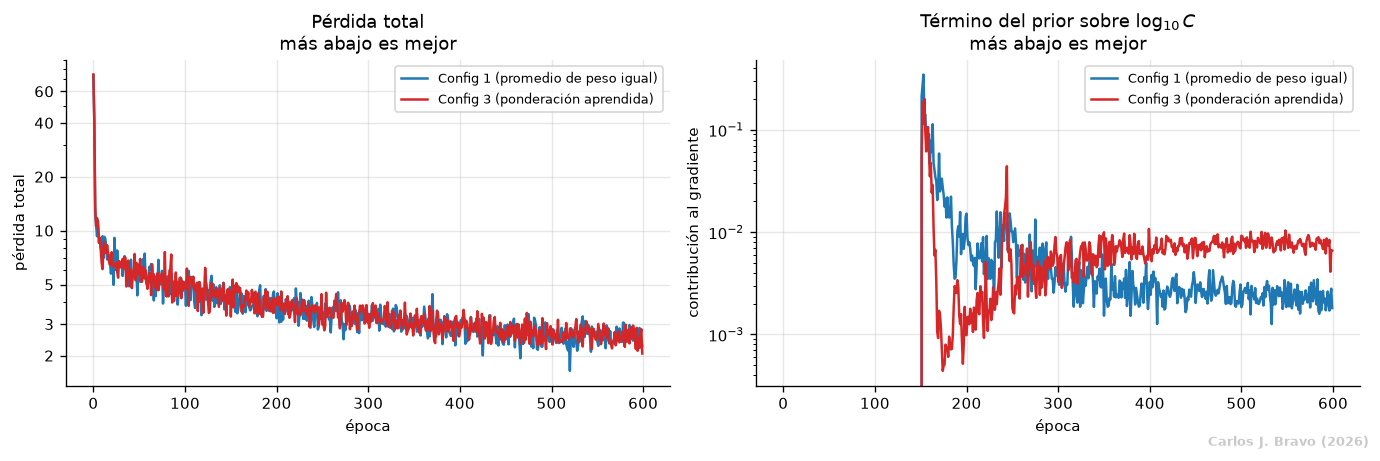

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
medias = {e: sum(pd.DataFrame(m.history_terms) for m in tandas[e][0]) / len(tandas[e][0])
          for e in (BASE, ATEN)}
for eje, columna, titulo in ((axes[0], "total", "Pérdida total"),
                             (axes[1], "prior_eff", "Término del prior sobre $\\log_{10}C$")):
    for etiqueta, color in ((BASE, "C0"), (ATEN, "C3")):
        eje.plot(medias[etiqueta].epoch, medias[etiqueta][columna], lw=1.5,
                 color=color, label=etiqueta)
    eje.set(xlabel="época", yscale="log", title=titulo + "\nmás abajo es mejor")
    eje.legend(fontsize=8)
axes[0].set_yticks([2, 3, 5, 10, 20, 40, 60])
axes[0].yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v:g}"))
axes[0].yaxis.set_minor_formatter(NullFormatter())
axes[0].set_ylabel("pérdida total")
axes[1].set_ylabel("contribución al gradiente")
marca_de_agua(fig)
fig.tight_layout(); plt.show()

El término del prior mide cuánto se aleja la cabeza del coeficiente del valor poblacional
identificado sobre los especímenes de entrenamiento. Es el único término de la pérdida que ve el
coeficiente, de modo que es el que el mecanismo añadido tendría que mover si estuviera cambiando lo
que la configuración pretende cambiar.

## 5. Evaluación sobre T7 y T8

Se reporta la primera tanda de semillas de cada arquitectura. La penalización oficial es la métrica
del certamen y la única directamente comparable con las tablas de clasificación. Menor es mejor.

In [6]:
for etiqueta in (BASE, ATEN):
    print(f"\n=== {etiqueta}")
    display(summarise(entregas[etiqueta]))


=== Config 1 (promedio de peso igual)


,espécimen,RMSE (mm),penalización,de la estimación,de la prognosis,log10 C predicho,log10 C implicado,correcciones monotonía
0,T7,0.3500,6.485,1.593,4.892,-8.423,-8.420,0
1,T8,2.4176,90.451,5.384,85.068,-8.423,-8.803,0



=== Config 3 (ponderación aprendida)


,espécimen,RMSE (mm),penalización,de la estimación,de la prognosis,log10 C predicho,log10 C implicado,correcciones monotonía
0,T7,0.5216,5.885,1.016,4.869,-8.407,-8.420,0
1,T8,2.4305,91.120,6.053,85.068,-8.434,-8.803,0


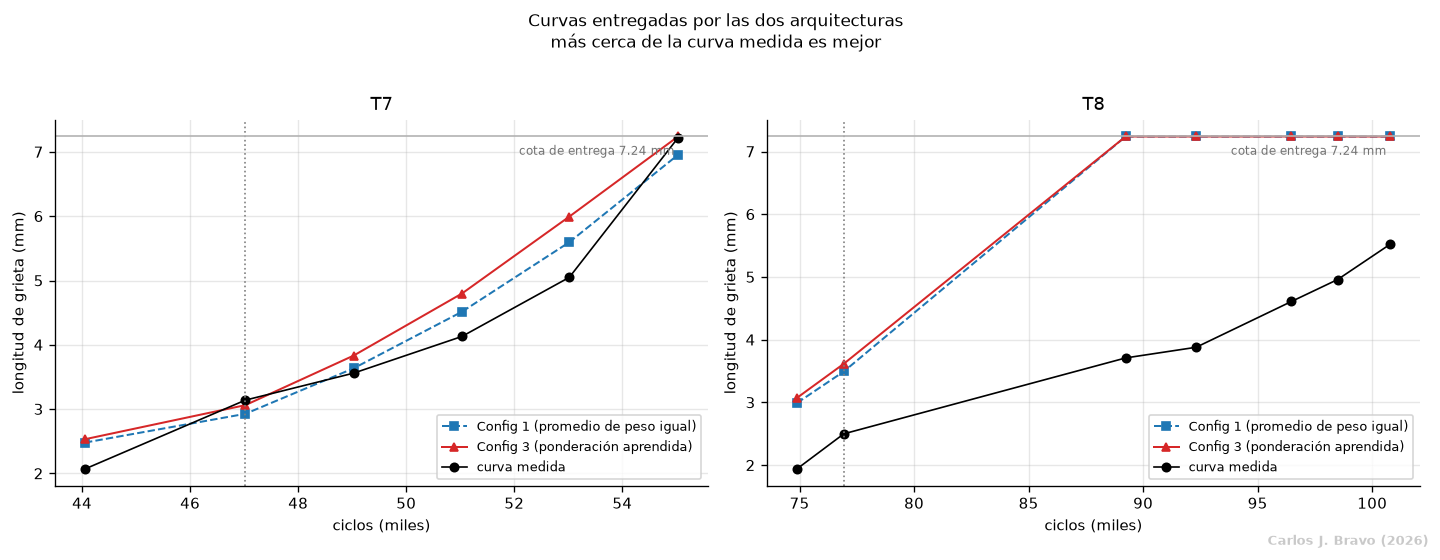

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))
ESTILO = {BASE: dict(color="C0", ls="--", marker="s"),
          ATEN: dict(color="C3", ls="-", marker="^")}
for ax, i in zip(axes, (0, 1)):
    for etiqueta in (BASE, ATEN):
        e = entregas[etiqueta][i]
        ax.plot(np.array(e["cycles"]) / 1e3, e["pred_mm"], ms=5, lw=1.2,
                label=etiqueta, **ESTILO[etiqueta])
    e = entregas[BASE][i]
    ax.plot(np.array(e["cycles"]) / 1e3, e["true_mm"], "ko-", ms=5, lw=1, label="curva medida")
    ax.axvline(e["cutoff_cycle"] / 1e3, color="0.5", ls=":", lw=1)
    ax.axhline(COTA, color="0.7", lw=1)
    ax.annotate(f"cota de entrega {COTA} mm", xy=(np.array(e["cycles"])[-1] / 1e3, COTA),
                xytext=(-2, -11), textcoords="offset points", fontsize=7, color="0.45",
                ha="right")
    ax.set(xlabel="ciclos (miles)", ylabel="longitud de grieta (mm)", title=e["specimen"])
    ax.legend(fontsize=7.5, loc="lower right")
fig.suptitle("Curvas entregadas por las dos arquitecturas\nmás cerca de la curva medida es mejor",
             y=1.02, fontsize=10)
marca_de_agua(fig)
fig.tight_layout(); plt.show()

## 6. Comparación con la Configuración 1

Ésta es la comparación que el estudio de ablación pide. Se acompaña de las referencias del certamen,
con las que la penalización es directamente comparable por espécimen.

In [8]:
def fila(etiqueta, ent):
    return {"variante": etiqueta,
            "pen T7": round(ent[0]["penalizacion"], 2),
            "pen T8": round(ent[1]["penalizacion"], 2),
            "total": round(ent[0]["penalizacion"] + ent[1]["penalizacion"], 2),
            "RMSE T7 (mm)": round(ent[0]["rmse_mm"], 3),
            "RMSE T8 (mm)": round(ent[1]["rmse_mm"], 3),
            "|Δlog10 C| T8": round(abs(ent[1]["log10_C_predicho"]
                                       - ent[1]["log10_C_implicado"]), 3)}


comparacion = pd.DataFrame([fila(e, entregas[e]) for e in (BASE, ATEN)])
display(comparacion)

referencias = pd.DataFrame(
    [{"entrada": k, "T7": v["T7"], "T8": v["T8"], "total": v["total"],
      "naturaleza": "publicada"} for k, v in PUBLICADO.items()]
    + [{"entrada": f"{k}, réplica", "T7": v["T7"], "T8": v["T8"], "total": v["total"],
        "naturaleza": "reproducible"} for k, v in REPLICA.items()])
display(referencias.set_index("entrada"))

,variante,pen T7,pen T8,total,RMSE T7 (mm),RMSE T8 (mm),|Δlog10 C| T8
0,Config 1 (promedio de peso igual),6.49,90.45,96.94,0.350,2.418,0.38
1,Config 3 (ponderación aprendida),5.88,91.12,97.00,0.522,2.431,0.37


,T7,T8,total,naturaleza
entrada,,,,
1.º Youn et al. (2019),3.415,3.944,7.359,publicada
2.º Kong et al. (2020),3.543,4.088,7.631,publicada
3.º Rao et al. (2020),9.229,6.864,16.093,publicada
"1.º Youn et al. (2019), réplica",22.708,91.600,114.309,reproducible
"2.º Kong et al. (2020), réplica",83.252,148.344,231.596,reproducible
"3.º Rao et al. (2020), réplica",215.123,25.787,240.910,reproducible


### 6.1 El recorrido entre semillas

Las diferencias de la tabla anterior son pequeñas, y con ochenta y siete ondas etiquetadas conviene
saber cuánto se mueve cada arquitectura al cambiar únicamente la semilla antes de atribuir una
diferencia al mecanismo. Las cuatro tandas de cada arquitectura dan esa medida.

In [9]:
filas = []
for etiqueta in (BASE, ATEN):
    for k, ent in enumerate(entregas_tanda[etiqueta]):
        filas.append({"variante": etiqueta, "tanda": k,
                      "pen T7": round(ent[0]["penalizacion"], 2),
                      "pen T8": round(ent[1]["penalizacion"], 2),
                      "total": round(ent[0]["penalizacion"] + ent[1]["penalizacion"], 2),
                      "RMSE T7 (mm)": round(ent[0]["rmse_mm"], 3),
                      "|Δlog10 C| T8": round(abs(ent[1]["log10_C_predicho"]
                                                 - ent[1]["log10_C_implicado"]), 3)})
dispersion = pd.DataFrame(filas)
resumen = dispersion.groupby("variante")[["pen T7", "pen T8", "total",
                                          "RMSE T7 (mm)", "|Δlog10 C| T8"]].agg(["min", "max"])
display(resumen.round(3))

for col in ("pen T7", "pen T8", "total", "RMSE T7 (mm)", "|Δlog10 C| T8"):
    a = dispersion.loc[dispersion.variante == BASE, col]
    b = dispersion.loc[dispersion.variante == ATEN, col]
    solapan = a.min() <= b.max() and b.min() <= a.max()
    print(f"{col:15s} base [{a.min():7.3f}, {a.max():7.3f}] | atención "
          f"[{b.min():7.3f}, {b.max():7.3f}] -> "
          f"{'se solapan, diferencia no atribuible al mecanismo' if solapan else 'NO se solapan'}")

pen T7       pen T8         total        RMSE T7 (mm)        |Δlog10 C| T8       
                                     min   max    min    max    min    max          min    max           min    max
variante                                                                                                           
Config 1 (promedio de peso igual)   5.02  6.94  90.45  90.93  95.66  97.87        0.330  0.432         0.371  0.380
Config 3 (ponderación aprendida)    5.03  5.88  90.77  91.24  96.14  97.00        0.436  0.522         0.348  0.392

pen T7          base [  5.020,   6.940] | atención [  5.030,   5.880] -> se solapan, diferencia no atribuible al mecanismo
pen T8          base [ 90.450,  90.930] | atención [ 90.770,  91.240] -> se solapan, diferencia no atribuible al mecanismo
total           base [ 95.660,  97.870] | atención [ 96.140,  97.000] -> se solapan, diferencia no atribuible al mecanismo
RMSE T7 (mm)    base [  0.330,   0.432] | atención [  0.436,   0.522] -> NO se solapan
|Δlog10 C| T8   base [  0.371,   0.380] | atención [  0.348,   0.392] -> se solapan, diferencia no atribuible al mecanismo


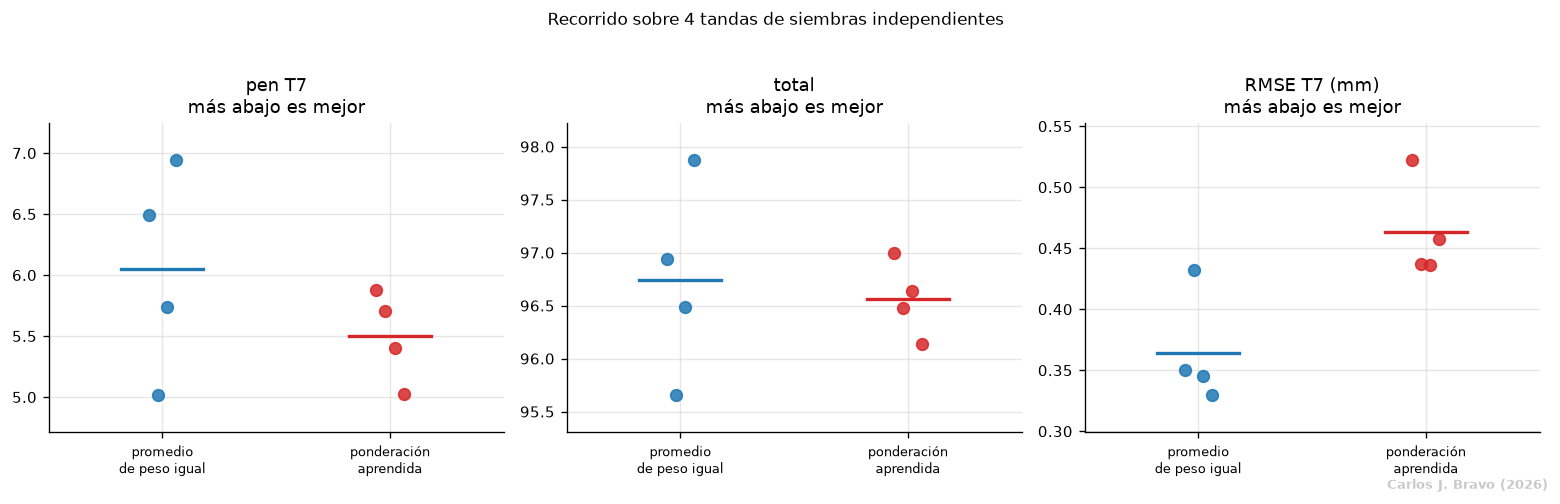

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.9))
for ax, col in zip(axes, ("pen T7", "total", "RMSE T7 (mm)")):
    for x, (etiqueta, color) in enumerate(((BASE, "C0"), (ATEN, "C3"))):
        v = dispersion.loc[dispersion.variante == etiqueta, col].to_numpy()
        ax.plot(np.full(len(v), x) + np.linspace(-.06, .06, len(v)), v, "o",
                color=color, ms=7, alpha=.85)
        ax.plot([x - .18, x + .18], [v.mean()] * 2, color=color, lw=2)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(["promedio\nde peso igual", "ponderación\naprendida"], fontsize=8)
    ax.set(title=col + "\nmás abajo es mejor", xlim=(-.5, 1.5))
    ax.margins(y=.16)
fig.suptitle(f"Recorrido sobre {N_TANDAS} tandas de semillas independientes", y=1.03, fontsize=10)
marca_de_agua(fig)
fig.tight_layout(); plt.show()

La lectura es la que fija lo que esta configuración puede afirmar.

En la penalización, que es la métrica del certamen, los recorridos de las dos arquitecturas se
solapan en las tres columnas: T7, T8 y el total. La mejor tanda del promedio de peso igual queda por
delante de la mejor tanda de la ponderación aprendida en T7, de modo que la diferencia entre las
medias no es atribuible al mecanismo, sino al recorrido propio de cada arquitectura al cambiar la
semilla. En la métrica que importa, las dos configuraciones empatan.

Sí hay dos hechos que se separan con claridad. El primero es que el recorrido de la ponderación
aprendida en T7 es apreciablemente más estrecho que el del promedio de peso igual: el mecanismo
reduce la sensibilidad a la semilla aunque no mueva el resultado medio. El segundo va en su contra,
y es que el error cuadrático medio de T7 empeora de forma sistemática, con recorridos que no se
tocan. La ponderación obtiene la misma penalización con un error mayor en media cuadrática, lo que
indica que cambia el perfil del error y no su magnitud.

Sobre el coeficiente de T8, que era el objetivo declarado del componente, los recorridos también se
solapan. El apartado 8 explica por qué eso ocurre y por qué no depende de la arquitectura.

## 7. La ponderación que el mecanismo aprende

La expectativa de partida es que la ponderación descuente el ciclo de referencia sano y dé peso a los
que informan del crecimiento. Es una afirmación contrastable, porque el peso que la consulta aprendida
asigna a cada ciclo puede leerse directamente.

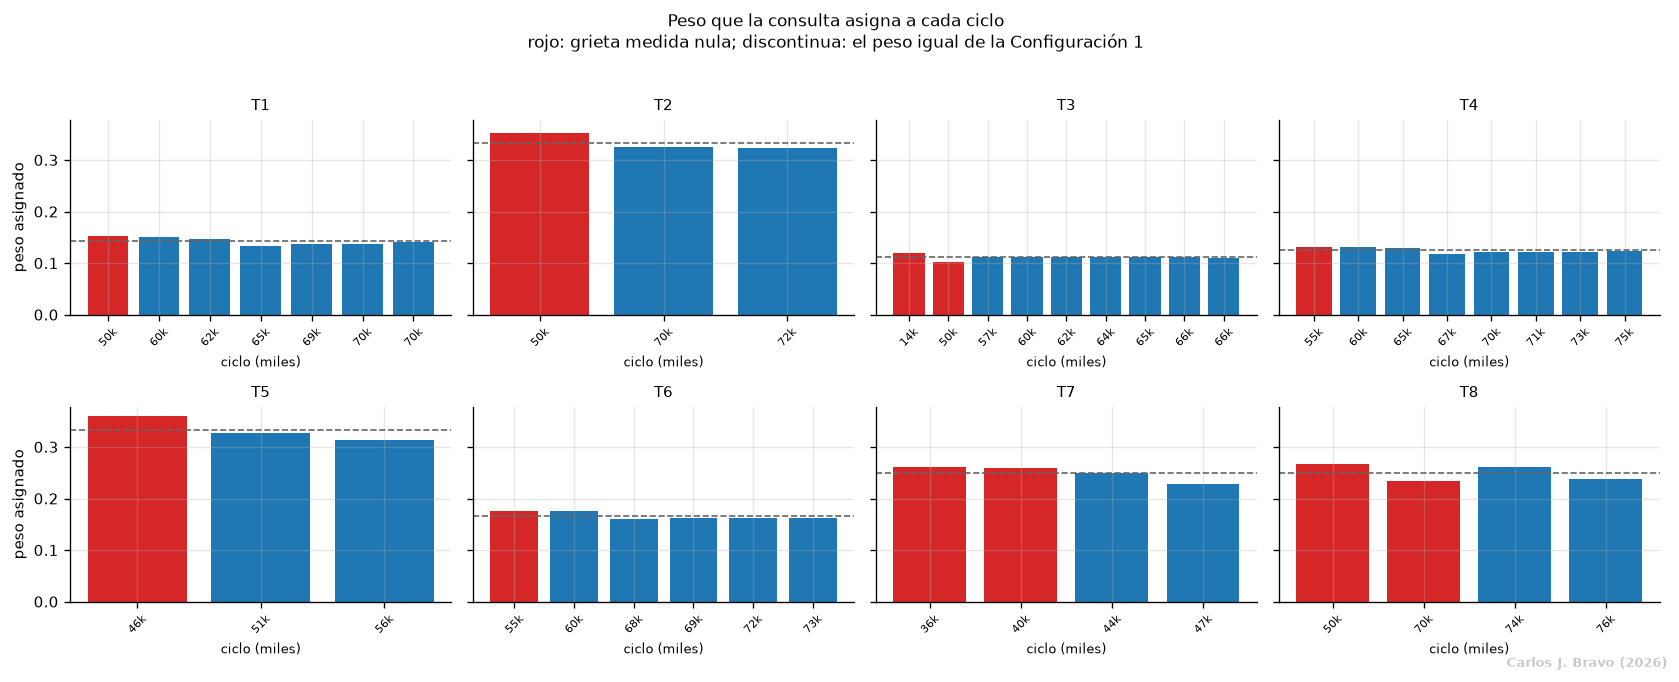

In [11]:
modelo = tandas[ATEN][0][0]
modelo.eval()

pesos = {}
with torch.no_grad():
    for nombre, b in lotes.items():
        z = modelo.encoder(b.x)
        idx = torch.zeros(len(b.x), dtype=torch.long)
        modelo.log_c(z, idx, 1, b.cycles, b.log_dn)
        pesos[nombre] = (torch.unique(b.cycles).numpy(),
                         np.atleast_1d(modelo.attention.last_weights.squeeze().numpy()))

fig, axes = plt.subplots(2, 4, figsize=(14, 5.4), sharey=True)
for ax, (nombre, (ciclos, w)) in zip(axes.ravel(), pesos.items()):
    tabla = etiquetas[nombre]
    grietas = {float(c): float(a) for c, a in zip(tabla["cycle"], tabla["crack_length_mm"])}
    colores = ["C3" if grietas.get(float(c), 1.0) == 0.0 else "C0" for c in ciclos]
    ax.bar(range(len(w)), w, color=colores)
    ax.set_xticks(range(len(w)))
    ax.set_xticklabels([f"{int(c/1000)}k" for c in ciclos], fontsize=6.5, rotation=45)
    ax.axhline(1.0 / len(w), color="0.4", ls="--", lw=1)
    ax.set_title(nombre, fontsize=9)
    ax.set_xlabel("ciclo (miles)", fontsize=7.5)
axes[0, 0].set_ylabel("peso asignado")
axes[1, 0].set_ylabel("peso asignado")
fig.suptitle("Peso que la consulta asigna a cada ciclo\n"
             "rojo: grieta medida nula; discontinua: el peso igual de la Configuración 1", y=1.02,
             fontsize=10)
marca_de_agua(fig)
fig.tight_layout(); plt.show()

In [12]:
filas = []
for nombre, (ciclos, w) in pesos.items():
    tabla = etiquetas[nombre]
    grietas = {float(c): float(a) for c, a in zip(tabla["cycle"], tabla["crack_length_mm"])}
    cero = np.array([grietas.get(float(c), 1.0) == 0.0 for c in ciclos])
    if cero.any() and (~cero).any():
        filas.append({"espécimen": nombre, "ciclos": len(w),
                      "peso medio sin grieta": round(float(w[cero].mean()), 4),
                      "peso medio con grieta": round(float(w[~cero].mean()), 4),
                      "razón": round(float(w[cero].mean() / w[~cero].mean()), 3),
                      "peso igual sería": round(1.0 / len(w), 4)})
razones = pd.DataFrame(filas)
if not len(razones):
    raise RuntimeError("ningún espécimen tiene a la vez ciclos con grieta nula y no nula")
display(razones)
print(f"Especímenes con ciclos de ambos tipos: {len(razones)} de {len(pesos)}")
print(f"Razón mediana: {razones['razón'].median():.3f} | "
      f"recorrido: {razones['razón'].min():.3f} a {razones['razón'].max():.3f}")
print(f"Especímenes con razón mayor que 1: {int((razones['razón'] > 1).sum())} de {len(razones)}")

,espécimen,ciclos,peso medio sin grieta,peso medio con grieta,razón,peso igual sería
0,T1,7,0.1536,0.1411,1.089,0.1429
1,T2,3,0.3517,0.3241,1.085,0.3333
2,T3,9,0.1107,0.1112,0.995,0.1111
3,T4,8,0.1311,0.1241,1.056,0.1250
4,T5,3,0.3596,0.3202,1.123,0.3333
5,T6,6,0.1762,0.1648,1.069,0.1667
6,T7,4,0.2604,0.2396,1.087,0.2500
7,T8,4,0.2501,0.2499,1.001,0.2500


Especímenes con ciclos de ambos tipos: 8 de 8
Razón mediana: 1.077 | recorrido: 0.995 a 1.123
Especímenes con razón mayor que 1: 7 de 8


### 7.1 Lo que la medida establece

Una razón menor que 1 significaría que la ponderación descuenta los ciclos sin grieta, que es lo que
la expectativa de partida sostenía. La medida da lo contrario en siete de los ocho especímenes, pero
el hallazgo que pesa es la magnitud: las razones se mueven en un margen estrecho alrededor de la
unidad y los pesos por ciclo quedan muy próximos al reparto uniforme que el mecanismo venía a
sustituir.

De ahí salen dos conclusiones, y ambas cuentan. La expectativa de partida queda sin respaldo, porque
la ponderación no descuenta la referencia sana sino que tiende a favorecerla ligeramente. Y el
mecanismo apenas se aparta del promedio de peso igual, lo que explica por sí solo el empate del
apartado 6: si la ponderación aprendida converge a algo muy próximo al reparto uniforme, la cabeza
del coeficiente recibe casi la misma entrada en las dos arquitecturas y devuelve casi la misma
salida.

Conviene un matiz sobre la dirección del sesgo. Un peso algo mayor sobre el registro sano no es
automáticamente un defecto, porque ese registro es la referencia contra la que se define el canal
diferencial de todos los demás, de modo que puede portar información de normalización legítima. Lo
que queda establecido es que la ponderación no hace lo que la hipótesis afirmaba, y que ésta no puede
invocarse para explicar ninguna diferencia de resultado.


## 8. El alcance de la ponderación sobre T8

El apartado 6 muestra que el coeficiente de T8 no se mueve. La medida que sigue establece por qué, y
lo hace sin entrenar nada: es una propiedad de los datos y no del modelo.

El coeficiente de la ley de crecimiento puede ajustarse por tramos directamente sobre la curva
medida, sin intervención de ninguna red. Comparar lo que implica el tramo que el estimador puede leer
con lo que implica el tramo que no ve delimita lo que cualquier estimador podría llegar a deducir.

In [13]:
filas = []
for nombre in ("T7", "T8"):
    cur = load_curve(nombre)
    d_sigma = equivalent_stress_range(cur.load_block, cfg_base.m_exponent)
    ciclos = np.asarray(cur.cycles, dtype=float)
    grieta = np.asarray(cur.crack_mm, dtype=float)
    nz = grieta > 0
    k = n_observed_nonzero(nombre)
    filas.append({
        "espécimen": nombre,
        "espectro": "variable" if cur.is_variable_amplitude else "constante",
        "ventana observada": round(float(fit_log_c(ciclos[nz][:k], grieta[nz][:k],
                                                   cfg_base.m_exponent, d_sigma)), 4),
        "curva completa": round(float(fit_log_c(ciclos, grieta,
                                                cfg_base.m_exponent, d_sigma)), 4),
        "ventana ciega": round(float(fit_log_c(ciclos[nz][k-1:], grieta[nz][k-1:],
                                               cfg_base.m_exponent, d_sigma)), 4),
    })
tramos = pd.DataFrame(filas)
display(tramos)

obs7, obs8 = float(tramos.loc[0, "ventana observada"]), float(tramos.loc[1, "ventana observada"])
cie7, cie8 = float(tramos.loc[0, "ventana ciega"]), float(tramos.loc[1, "ventana ciega"])
print(f"En la ventana observada, que es la única que el estimador lee, T7 y T8 implican")
print(f"coeficientes que difieren en {abs(obs8-obs7):.4f} dex.")
print(f"En la ventana ciega, que ningún estimador ve, la diferencia pasa a {abs(cie8-cie7):.4f} dex.")
print(f"\nRango que la cabeza del coeficiente puede emitir: "
      f"{cfg_base.log_c_prior:.3f} ± {cfg_base.log_c_range:.1f} dex, "
      f"es decir hasta {cfg_base.log_c_prior - cfg_base.log_c_range:.3f}.")
print("La capacidad, por tanto, no es la restricción.")

,espécimen,espectro,ventana observada,curva completa,ventana ciega
0,T7,constante,-8.310,-8.4202,-8.4797
1,T8,variable,-8.317,-8.8035,-8.9050


En la ventana observada, que es la única que el estimador lee, T7 y T8 implican
coeficientes que difieren en 0.0070 dex.
En la ventana ciega, que ningún estimador ve, la diferencia pasa a 0.4253 dex.

Rango que la cabeza del coeficiente puede emitir: -8.426 ± 1.0 dex, es decir hasta -9.426.
La capacidad, por tanto, no es la restricción.


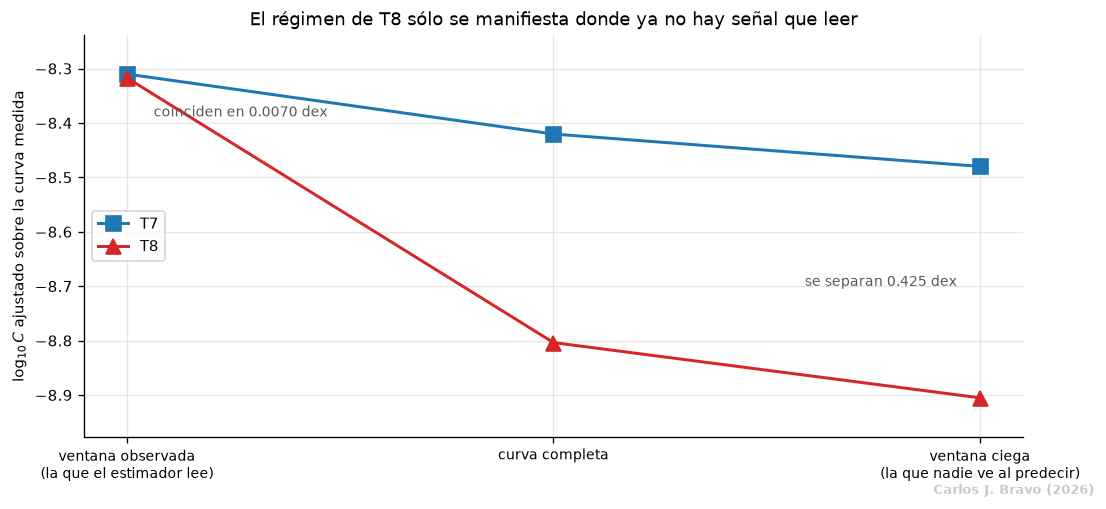

In [14]:
fig, ax = plt.subplots(figsize=(9.2, 4.2))
posiciones = np.arange(3)
for i, (nombre, color, marca) in enumerate((("T7", "C0", "s"), ("T8", "C3", "^"))):
    v = tramos.loc[tramos["espécimen"] == nombre,
                   ["ventana observada", "curva completa", "ventana ciega"]].to_numpy()[0]
    ax.plot(posiciones, v, marca + "-", color=color, ms=9, lw=1.8, label=nombre)
ax.set_xticks(posiciones)
ax.set_xticklabels(["ventana observada\n(la que el estimador lee)", "curva completa",
                    "ventana ciega\n(la que nadie ve al predecir)"], fontsize=8.5)
ax.annotate(f"coinciden en {abs(obs8-obs7):.4f} dex", xy=(0, (obs7 + obs8) / 2),
            xytext=(16, -22), textcoords="offset points", fontsize=8.5, color="0.35", va="center")
ax.annotate(f"se separan {abs(cie8-cie7):.3f} dex", xy=(2, (cie7 + cie8) / 2),
            xytext=(-14, 0), textcoords="offset points", fontsize=8.5, color="0.35",
            va="center", ha="right")
ax.set(ylabel=r"$\log_{10}C$ ajustado sobre la curva medida",
       title="El régimen de T8 sólo se manifiesta donde ya no hay señal que leer")
ax.legend(fontsize=9, loc="center left")
ax.margins(y=.12)
marca_de_agua(fig)
fig.tight_layout(); plt.show()

La medida cierra la cuestión y lo hace por una vía distinta de la que limita a la Configuración 2.

En la ventana que cualquier estimador puede leer, T7 y T8 implican prácticamente el mismo
coeficiente: difieren en milésimas de década. Sólo se separan después del corte de señal, donde ya no
hay nada que medir. La información que permitiría distinguirlas no está en la entrada, de manera que
ninguna ponderación de esas entradas puede producir dos coeficientes distintos. La restricción no es
la capacidad del mecanismo, que puede emitir cualquier valor dentro de una década completa y alcanza
de sobra el que T8 necesitaría, sino la identificabilidad.

Hay además una consecuencia que refuerza la conclusión. Como las dos probetas resultan
indistinguibles en la ventana legible, cualquier desplazamiento del coeficiente que corrigiese a T8
se aplicaría también a T7 y la empeoraría. No existe una ponderación que baje una y respete la otra.

Lo único que sí distingue a las dos probetas es el espectro de carga, que se conoce de antemano. Pero
aprender que la amplitud variable implica un coeficiente menor exigiría al menos un ejemplo de
entrenamiento de ese régimen, y no hay ninguno. La alternativa es imponer la corrección desde la
física en vez de aprenderla, que es la vía de la Configuración 2 y donde el mecanismo de retardo se
queda corto por su propio techo estructural.

## 9. Conclusiones

1. **En la penalización oficial, que es la métrica del certamen, la ponderación aprendida empata con
   el promedio de peso igual.** Los recorridos sobre semillas independientes se solapan en T7, en T8
   y en el total, y la mejor tanda de la configuración base queda por delante de la mejor tanda de
   ésta en T7. La diferencia entre las medias no es atribuible al mecanismo.
2. **El error cuadrático medio de T7 empeora de forma sistemática**, con recorridos que no se tocan.
   El mecanismo obtiene la misma penalización con un error mayor en media cuadrática, de modo que
   cambia el perfil del error y no su magnitud. Es el único efecto que se separa con claridad, y va
   en contra del componente.
3. **El mecanismo sí reduce la sensibilidad a la semilla** en T7, con un recorrido apreciablemente
   más estrecho. Es una ventaja real, aunque no se traduzca en la métrica del certamen.
4. **La ponderación apenas se separa del promedio que venía a sustituir.** Los pesos por ciclo
   quedan muy próximos al reparto uniforme, con razones entre los ciclos sin daño y los que informan
   del crecimiento que se mueven en un margen estrecho alrededor de la unidad. La expectativa de que
   descontase la referencia sana queda sin respaldo, y la proximidad al reparto uniforme explica por
   sí sola el empate del apartado 6.
5. **El coeficiente de T8 queda fuera del alcance de cualquier ponderación, y no por la
   arquitectura.** En la ventana con señal T7 y T8 implican coeficientes que difieren en milésimas de
   década, y sólo se separan en la ventana ciega. La información no está en la entrada. El mecanismo
   podría emitir el valor que T8 necesita, de modo que la restricción es de identificabilidad y no de
   capacidad.
6. **El coste es bajo** y el mecanismo es el mínimo con el que la ponderación es posible a este
   tamaño de muestra: una capa, dos cabezales, sobre la dimensión latente ya existente.

## 10. Limitaciones

* **La atención es bidireccional y por tanto transductiva:** cada ciclo ve ondas posteriores del
  mismo espécimen bajo prueba. Es admisible bajo el protocolo del certamen, que entregaba el conjunto
  completo de señales de cada espécimen de validación de una vez, pero no sería posible en línea. Es
  la misma limitación que la normalización por espécimen.
* **Las secuencias tienen entre tres y nueve ciclos**, un régimen muy alejado de aquel en el que la
  autoatención ha sido validada en la literatura.
* **La hipótesis del régimen de carga no es contrastable** con este conjunto de datos, porque no
  contiene ningún espécimen de entrenamiento de amplitud variable, y eso no se resuelve con
  arquitectura.
* **El recorrido entre semillas se mide sobre cuatro tandas.** Es suficiente para descartar las
  diferencias que quedan dentro de él, pero no para estimar con precisión la magnitud de las que
  quedan fuera.

## Los pesos entrenados

Los conjuntos que este cuaderno ha usado quedan guardados en `models/`, de modo que una ejecución
posterior los carga en lugar de repetir el entrenamiento. Como la siembra está fijada, cargar y
reentrenar producen los mismos pesos bit a bit; lo que cambia es el tiempo.


In [ ]:
print(inventario())
